In [105]:
from itertools import product
from functools import reduce

import scipy as sc
from cirq_sic.wh import wh_povm
from cirq_sic.sics import load_sic_fiducial
from cirq_sic.utils import kron, rand_ket

import numpy as np
np.set_printoptions(precision=3, suppress=True)

from bell import *

import matplotlib.pyplot as plt

In [106]:
def rand_mic(d):
    K = sc.stats.unitary_group.rvs(d**3)[:, :d].reshape(d**2,d,d)
    E = np.einsum("ikj, ikc->ijc", K.conj(), K)
    return E

In [108]:
d = 2
n_parties = 2
bell_functional, classical_bound = chsh_inequality()

def chsh_family(theta):
    observables = np.array([[Z, X], [np.cos(theta)*Z+np.sin(theta)*X, np.cos(theta)*Z - np.sin(theta)*X]])
    ket = np.array([0,1,-1,0])/np.sqrt(2)
    return observables, np.outer(ket, ket.conj())

def generate_data(reference_measurements):
    reference_states = np.array([[e/e.trace() for e in reference_measurements[i]] for i in range(n_parties)])
    thetas = np.linspace(0, 2*np.pi, 100)
    bounds = []
    chsh_values = []
    sigma_maxes = []
    Deltas = []
    for theta in thetas:
        observables, state = chsh_family(theta)
        bell_povms = construct_povms_from_observables(observables)
        p = quantum_behavior_from_povms(bell_povms, state)

        T, T_meta = construct_T(state, bell_povms, reference_measurements, reference_states, return_metadata=True)
        phi = T_meta["phi"]
        #assert np.allclose(p, T @ phi)

        T_singular_values = np.linalg.svd(T, compute_uv=False)
        chsh_value =  bell_functional @ p 
        Delta = chsh_value - classical_bound
        sigma_max = np.max(T_singular_values)
        bound = Delta/(sigma_max*np.linalg.norm(bell_functional))

        chsh_values.append(chsh_value)
        sigma_maxes.append(sigma_max)
        Deltas.append(Delta)
        bounds.append(bound)
    return {"thetas": thetas, "bounds": bounds, "chsh_values": chsh_values, "sigma_maxes": sigma_maxes, "Deltas": Deltas}

In [112]:
sic_measurement = np.array([wh_povm(load_sic_fiducial(d)) for i in range(n_parties)])
rand_whpovm_measurement = np.array([wh_povm(rand_ket(d)) for i in range(n_parties)])
rand_povm_measurement = np.array([rand_mic(d) for i in range(n_parties)])

sic_data = generate_data(sic_measurement)
rand_whpovm_data = generate_data(rand_whpovm_measurement)
rand_povm_data = generate_data(rand_povm_measurement)

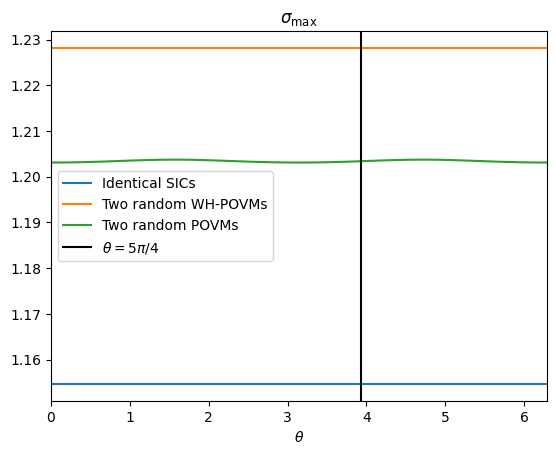

In [114]:
fig, ax = plt.subplots()
ax.plot(sic_data["thetas"], sic_data["sigma_maxes"], label=r"Identical SICs")
ax.plot(rand_whpovm_data["thetas"], rand_whpovm_data["sigma_maxes"], label=r"Two random WH-POVMs")
ax.plot(rand_povm_data["thetas"], rand_povm_data["sigma_maxes"], label=r"Two random POVMs")

ax.axvline(np.pi/4 + np.pi, color="black", label=r"$\theta=5 \pi/4$")

ax.set_xlabel(r"$\theta$")
ax.legend() 

ax.set_title(r"$\sigma_{\max}$")
ax.set_xlim(0, 2*np.pi)
plt.show()

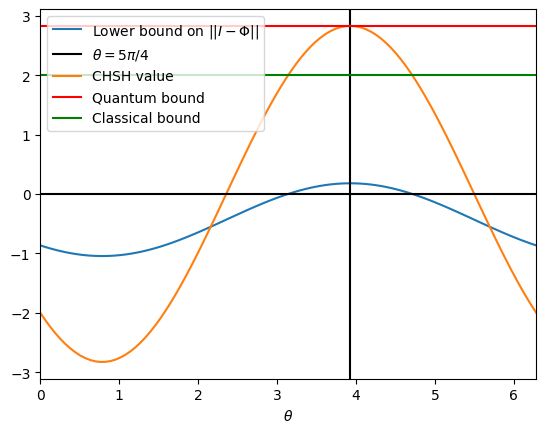

In [121]:
fig, ax = plt.subplots()
ax.plot(sic_data["thetas"], sic_data["bounds"], label=r"Lower bound on $|| I - \Phi ||$")
#ax.plot(sic_data["thetas"], sic_data["sigma_maxes"], label=r"$\sigma_{\max}$")
#ax.plot(sic_data["thetas"], sic_data["Deltas"], label=r"$\Delta$")
ax.axvline(np.pi/4 + np.pi, color="black", label=r"$\theta=5 \pi/4$")

ax.plot(thetas, chsh_values, label="CHSH value")
ax.axhline(2*np.sqrt(2), color="red", label=r"Quantum bound")
ax.axhline(2, color="green", label=r"Classical bound")

ax.axhline(0, color="black")
ax.set_xlabel(r"$\theta$")
ax.legend() 

ax.set_xlim(0, 2*np.pi)
plt.show()
fig.savefig("theta_bell.pdf")